# MIN1PIPE Visualization Reproduction (MATLAB-Aligned)

This notebook reproduces the six MATLAB demo visualizations from `demo_min1pipe.m` using canonical processed artifacts.

## Setup

In [1]:
from pathlib import Path
import numpy as np
from IPython.display import Image, display

from min1pipe.io import load_processed_mat
from min1pipe.matlab_mirror.demo_min1pipe import render_demo_visualization
from min1pipe.matlab_mirror.min1pipe import min1pipe

## Load Canonical Processed Output

In [2]:
cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / 'pyproject.toml').exists()), cwd)
ref_processed = repo_root / 'artifacts' / 'golden' / 'matlab' / 'demo_data' / 'latest' / 'demo_data_data_processed.mat'

if ref_processed.exists():
    source_layout = 'matlab'
    processed_path = ref_processed
else:
    source_layout = 'python'
    fname, _, _ = min1pipe(20, 20, None, None, True, 1)
    processed_path = Path(fname)

data = load_processed_mat(processed_path, source_layout=source_layout)
print('Repo root:', repo_root)
print('Source layout:', source_layout)
print('Processed file:', processed_path)

Repo root: /home/yz/MIN1PIPE
Source layout: matlab
Processed file: /home/yz/MIN1PIPE/artifacts/golden/matlab/demo_data/latest/demo_data_data_processed.mat


## Reproduce All MATLAB Demo Visualizations

Panels in output figure correspond to:
1. `Raw` (`demo_min1pipe.m`, subplot 2x3 #1)
2. `Before MC` (`demo_min1pipe.m`, subplot 2x3 #2)
3. `After MC` (`demo_min1pipe.m`, subplot 2x3 #3)
4. `Neural Contours` (`utilities/postprocess/plot_contour.m`)
5. `MC Scores` (`demo_min1pipe.m`, subplot 2x3 #5)
6. `Traces` (`demo_min1pipe.m`, subplot 2x3 #6)

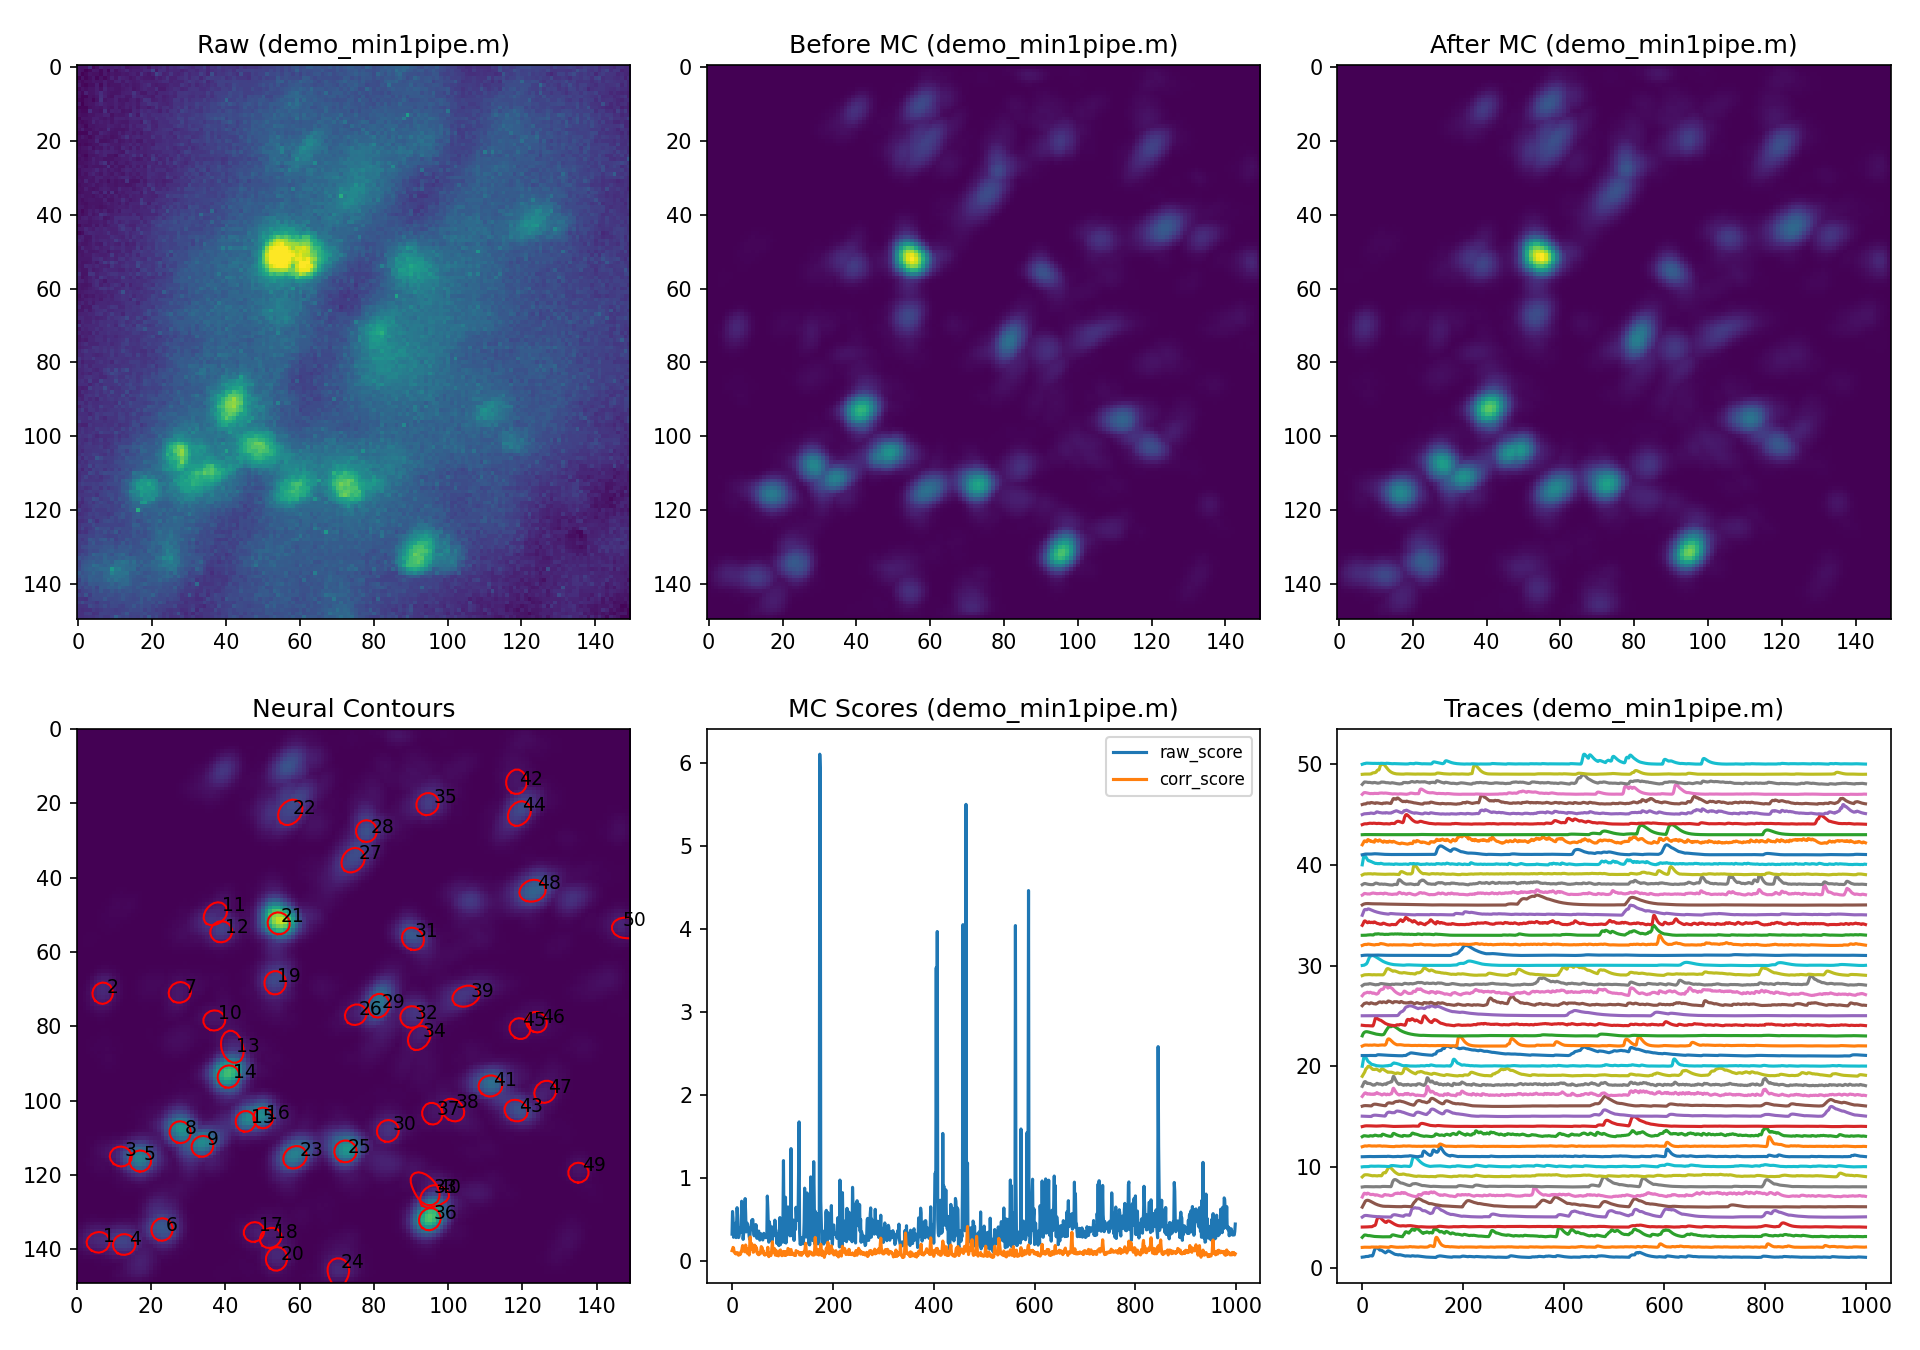

PosixPath('/home/yz/MIN1PIPE/demo/demo_visualization_python_notebook.png')

In [3]:
out_path = repo_root / 'demo' / 'demo_visualization_python_notebook.png'
render_demo_visualization(data=data, out_path=out_path, title_suffix='(demo_min1pipe.m)')
display(Image(filename=str(out_path)))
out_path

## Quick Diagnostics

In [4]:
print('imax shape:', data['imax'].shape)
print('roifn shape:', data['roifn'].shape)
print('sigfn shape:', data['sigfn'].shape)
print('raw_score max:', float(np.max(data['raw_score'])))
print('corr_score max:', float(np.max(data['corr_score'])))

imax shape: (150, 150)
roifn shape: (22500, 50)
sigfn shape: (50, 1000)
raw_score max: 6.106566429138184
corr_score max: 0.41180625557899475
